In [2]:
# 导包
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from debugpy import connect
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['STHeiti']

df = pd.read_csv('data/house_sales.csv')
df.drop(columns='origin_url',inplace=True)
df.dropna(inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 57520 entries, 0 to 106089
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   city      57520 non-null  str  
 1   address   57520 non-null  str  
 2   area      57520 non-null  str  
 3   floor     57520 non-null  str  
 4   name      57520 non-null  str  
 5   price     57520 non-null  str  
 6   province  57520 non-null  str  
 7   rooms     57520 non-null  str  
 8   toward    57520 non-null  str  
 9   unit      57520 non-null  str  
 10  year      57520 non-null  str  
dtypes: str(11)
memory usage: 5.3 MB


In [3]:
# 检查是否有重复值
df.drop_duplicates(inplace=True)

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建
2,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37㎡,中层（共22层）,文一名门金隅,32万,安徽,2室1厅,南北向,8649元/㎡,2017年建
6,合肥,龙岗-长江东路与和县里交口,50㎡,高层（共30层）,柏庄金座,46万,安徽,2室1厅,南向,9200元/㎡,2019年建
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120㎡,中层（共27层）,天目未来,158万,安徽,4室2厅,南向,13167元/㎡,2012年建


In [6]:
df['area'] = df['area'].str.replace('㎡','').astype('float')

In [8]:
df['price'] = df['price'].str.replace('万','').astype('float')

In [10]:
df['year'] = df['year'].str.replace('年建','').astype('int')

In [12]:
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222元/㎡,2013
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895元/㎡,2019
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649元/㎡,2017
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200元/㎡,2019
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167元/㎡,2012


In [13]:
df['unit'] = df['unit'].str.replace('元/㎡','').astype('float')
df['toward'] = df['toward'].astype('category')

In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 28104 entries, 0 to 106088
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   city      28104 non-null  str     
 1   address   28104 non-null  str     
 2   area      28104 non-null  float64 
 3   floor     28104 non-null  str     
 4   name      28104 non-null  str     
 5   price     28104 non-null  float64 
 6   province  28104 non-null  str     
 7   rooms     28104 non-null  str     
 8   toward    28104 non-null  category
 9   unit      28104 non-null  float64 
 10  year      28104 non-null  int64   
dtypes: category(1), float64(3), int64(1), str(6)
memory usage: 2.4 MB


In [18]:
# 异常值的处理
df = df[(df['area'] < 600) & (df['area'] > 20)]

In [21]:
# 房屋售价异常异常值处理 IQR
Q1 = df['price'].quantile(0.25)
Q2 = df['price'].quantile(0.75)
IQR = Q2 - Q1
lower_price = Q1 - 1.5 * IQR
upper_price = Q2 + 1.5 * IQR
df = df[(df['price'] < upper_price) & (df['price'] > lower_price)]

In [24]:
df.info()
df.head()

<class 'pandas.DataFrame'>
Index: 25382 entries, 0 to 106088
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   city      25382 non-null  str     
 1   address   25382 non-null  str     
 2   area      25382 non-null  float64 
 3   floor     25382 non-null  str     
 4   name      25382 non-null  str     
 5   price     25382 non-null  float64 
 6   province  25382 non-null  str     
 7   rooms     25382 non-null  str     
 8   toward    25382 non-null  category
 9   unit      25382 non-null  float64 
 10  year      25382 non-null  int64   
dtypes: category(1), float64(3), int64(1), str(6)
memory usage: 2.2 MB


,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012


In [30]:
# 构造新数据
df['district'] = df['address'].str.split('-').str[0]

In [42]:
df['floor_level'] = df['floor'].str[:2].astype('category')

In [45]:
df['is_zxs'] = df['city'].apply(lambda x:True if x in ['北京','上海','天津','重庆'] else False)

In [53]:
df[df['is_zxs']]

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district,floor_level,is_zxs
12,重庆,礼嘉-光照路附近 (金通大道与金海大道交界处步行5,123.00,低层（共8层）,礼悦江山,176.5,直辖市,4室2厅,南向,14350.0,2019,礼嘉,低层,True
26,重庆,天星桥-小龙坎正街369号,57.00,高层（共26层）,融侨诺丁阳光,80.0,直辖市,1室1厅,南向,14035.0,2007,天星桥,高层,True
28,重庆,凤天路-凤西路一站,100.00,低层（共32层）,华宇城,160.0,直辖市,3室2厅,南北向,16000.0,2016,凤天路,低层,True
30,重庆,龙兴-两江新区龙兴两江大道,131.00,中层（共12层）,协信哈罗国际,145.0,直辖市,4室2厅,南向,11069.0,2017,龙兴,中层,True
32,重庆,一号桥-重庆市渝中区黄花园双钢路(两江丽景旁),88.40,高层（共32层）,康田国际,135.0,直辖市,2室2厅,南向,15271.0,2009,一号桥,高层,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1022,天津,八里台镇-天嘉湖大道西侧,103.68,高层（共9层）,中海国际公园城,108.0,直辖市,2室1厅,南北向,10417.0,2016,八里台镇,高层,True
1028,天津,双港镇-天津市津南区兴锋里附近,82.00,高层（共26层）,宝福家园,160.0,直辖市,2室1厅,南北向,19512.0,2013,双港镇,高层,True
1030,天津,宝坻城区-宝坻区南关大街与南三环路交口北侧,83.00,低层（共6层）,华苑东区,85.0,直辖市,2室2厅,南北向,10241.0,1995,宝坻城区,低层,True
1040,天津,东海街-河西区小海地微山路与三水道交口,61.00,高层（共6层）,三水南里,175.0,直辖市,2室1厅,南北向,28689.0,1990,东海街,高层,True


In [56]:
df['bedrooms'] = df['rooms'].str.split('室').str[0].astype(int)

In [57]:
df['livingrooms'] = df['rooms'].str.extract(r'(\d+)厅').astype('int')

In [59]:
df['building_age'] = 2026 - df['year']

In [64]:
df['price_level'] = pd.cut(df['price'],bins=4,labels=['低价','中价','高价','超高价'])

In [135]:
df

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district,floor_level,is_zxs,bedrooms,livingrooms,building_age,price_level
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.00,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013,龙岗,中层,False,3,2,13,中价
2,合肥,生态公园-淮海大道与大众路交口,95.00,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019,生态公园,中层,False,3,2,7,中价
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.00,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017,撮镇,中层,False,2,1,9,低价
6,合肥,龙岗-长江东路与和县里交口,50.00,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019,龙岗,高层,False,2,1,7,低价
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.00,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012,新亚汽车站,中层,False,4,2,14,高价
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106080,广元,万达广场-雪峰,61.11,中层（共6层）,富康小区,37.0,四川,2室2厅,南北向,6055.0,2012,万达广场,中层,False,2,2,14,低价
106082,广元,万达广场-广元市万源新区万源二街(南河4号桥直行100,89.94,中层（共26层）,南郡,73.0,四川,2室2厅,南向,8117.0,2016,万达广场,中层,False,2,2,10,低价
106084,广元,万达广场-广元市万源新区万源二街(南河4号桥直行100,85.00,高层（共25层）,南郡,75.0,四川,2室1厅,南向,8824.0,2016,万达广场,高层,False,2,1,10,中价
106086,广元,利州广场-广元市利州区兴安路519号,85.00,低层（共18层）,御景湾,86.0,四川,2室2厅,西南向,10118.0,2015,利州广场,低层,False,2,2,11,中价


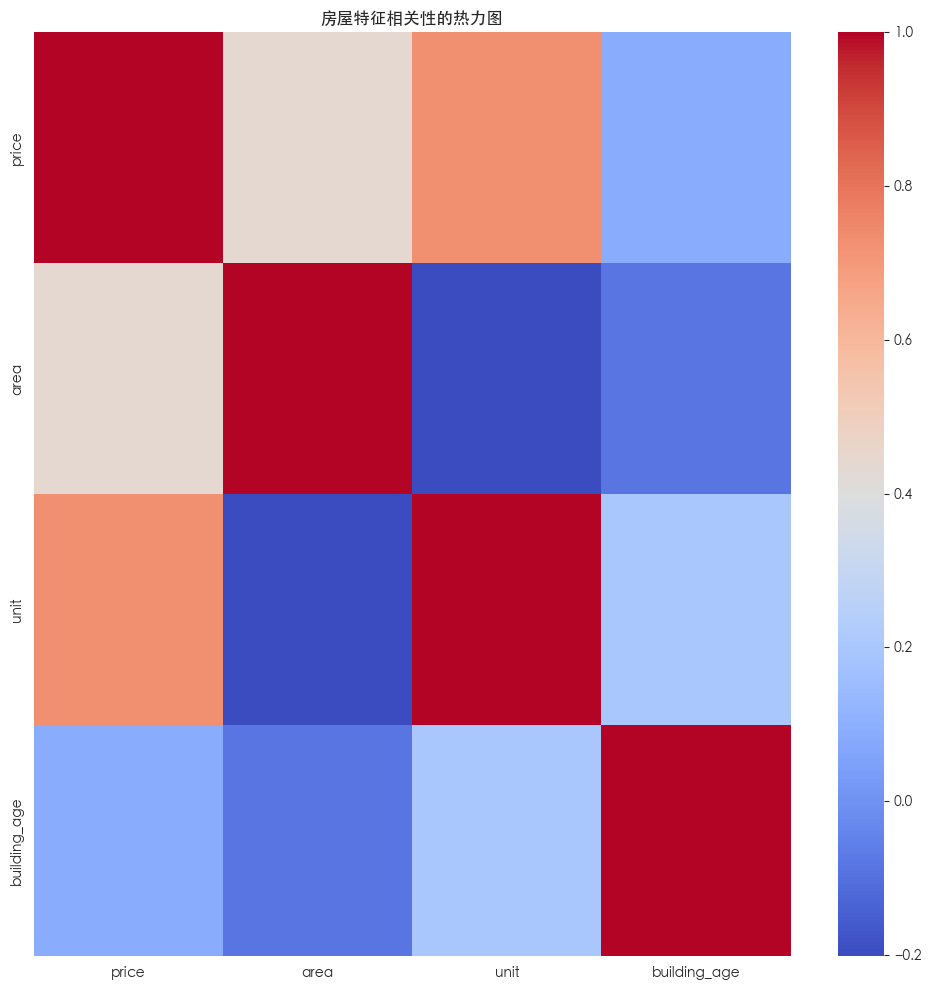

In [75]:
'''
问题编号: A1
问题: 哪些变量最影响房价？面积、楼层、房间数哪个影响更大？
分析主题: 特征相关性
分析目标: 了解房屋各特征对房价的线性影响
分组字段: 无
指标/方法: 皮尔逊相关系数
'''

a = df[['price','area','unit','building_age']].corr() # 相关性的系数
b = a['price'].sort_values(ascending=False)[1:] # 对房价影响因素最大的因子
#相关新热力图
plt.figure(figsize=(10,10))
sns.heatmap(a,cmap='coolwarm')
plt.title('房屋特征相关性的热力图')
plt.tight_layout()

In [77]:
'''
问题编号: A2
问题: 全国房价总体分布是怎样的？是否存在极端值？
分析主题: 描述性统计
分析目标: 概览数值型字段的分布特征
分组字段: 无
指标/方法: 平均数/中位数/四分位数/标准差
'''

df.describe()

,area,price,unit,year,bedrooms,livingrooms,building_age
count,25382.000000,25382.000000,25382.000000,25382.000000,25382.000000,25382.000000,25382.000000
mean,102.683130,112.218826,11273.759869,2013.105468,2.697305,1.845205,12.894532
std,32.827656,54.400754,5354.765656,6.024982,0.791970,0.407410,6.024982
min,21.000000,9.000000,1000.000000,1976.000000,0.000000,0.000000,3.000000
25%,85.000000,70.307500,7520.250000,2011.000000,2.000000,2.000000,9.000000
50%,99.000000,100.000000,10151.000000,2015.000000,3.000000,2.000000,11.000000
75%,122.000000,145.000000,13846.000000,2017.000000,3.000000,2.000000,15.000000
max,470.000000,266.300000,85288.000000,2023.000000,9.000000,12.000000,50.000000


<Axes: xlabel='price', ylabel='Count'>

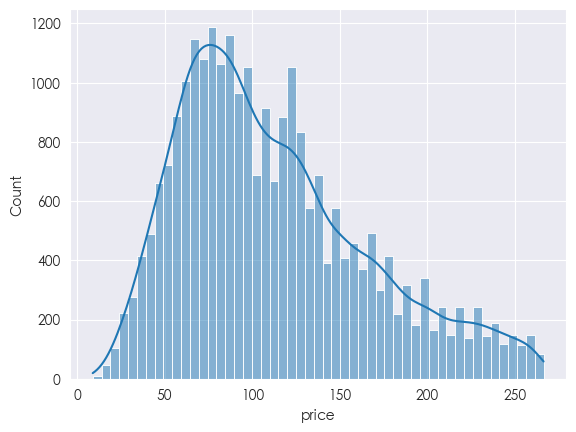

In [91]:
# 房价分布的直方图
plt.subplot(1,1,1)
sns.histplot(data=df,x='price',kde=True)

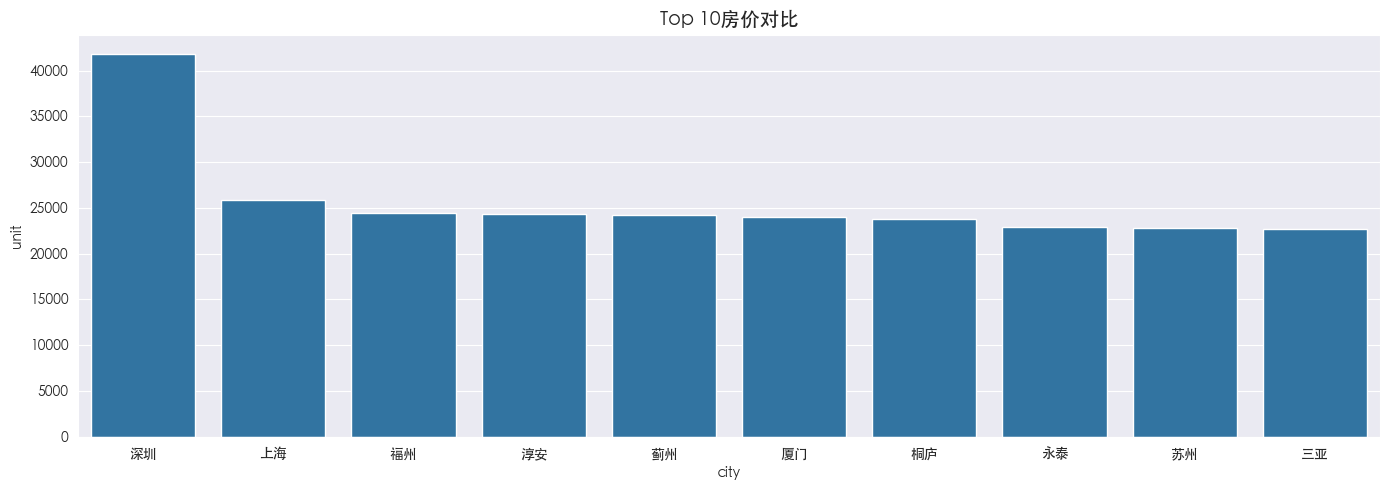

In [128]:
'''
问题编号: A3
问题: 哪些城市房价最高？直辖市与非直辖市差异如何？
分析主题: 城市对比
分析目标: 比较不同城市房价水平
分组字段: city
指标/方法: 均价/单价中位数/箱线图
'''
a = df.groupby('city').agg({
    'price':'mean',
    'unit':'mean'
})
a.sort_values(['unit','price'],ascending=False,inplace=True)
b = df.groupby('is_zxs').agg({
    'price':'mean',
    'unit':'mean'
})
c = a.head(10)
plt.figure(figsize=(14,5))
sns.barplot(data=c,x='city',y='unit')
plt.title('Top 10房价对比',fontsize=14)
plt.tight_layout()

area        building_age    is_zxs
                   mean median         mean      mean
price_level                                          
低价            83.494871   86.0    12.551351  0.004911
中价           103.717921  100.0    12.610098  0.007402
高价           115.817092  115.0    13.456886  0.009980
超高价          129.014233  128.0    14.221429  0.022381

Text(0, 0.5, '楼龄(年)')

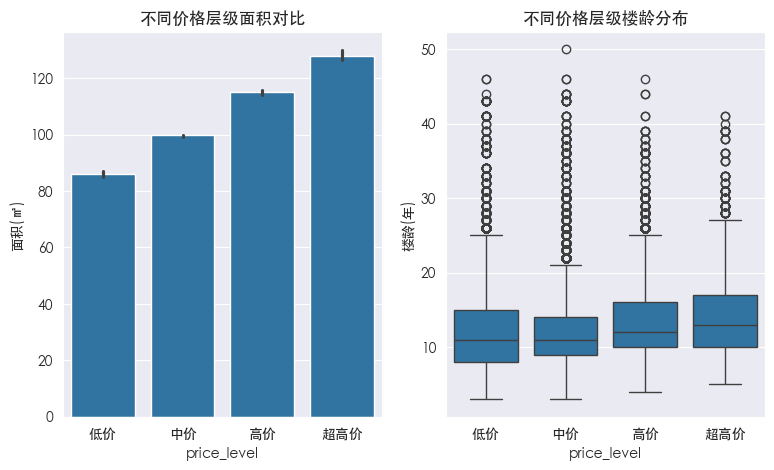

In [133]:
'''
问题编号: A4
问题: 高价房在面积、楼层等方面有什么特征？
分析主题: 价格分层
分析目标: 识别不同价位房屋特征差异
分组字段: 价格分段(低中高)
指标/方法: 列联表/卡方检验
'''
price_group = df.groupby('price_level').agg({
    'area':['mean','median'],
    'building_age':'mean',
    'is_zxs':'mean' # 直辖市占比
})
display(price_group)
# 可视化
plt.figure(figsize=(14, 5))

plt.subplot(131)
sns.barplot(x='price_level', y='area', data=df, estimator=np.median)
plt.title('不同价格层级面积对比')
plt.ylabel('面积(㎡)')

plt.subplot(132)
sns.boxplot(x='price_level', y='building_age', data=df)
plt.title('不同价格层级楼龄分布')
plt.ylabel('楼龄(年)')

Text(0.5, 0, '房间数')

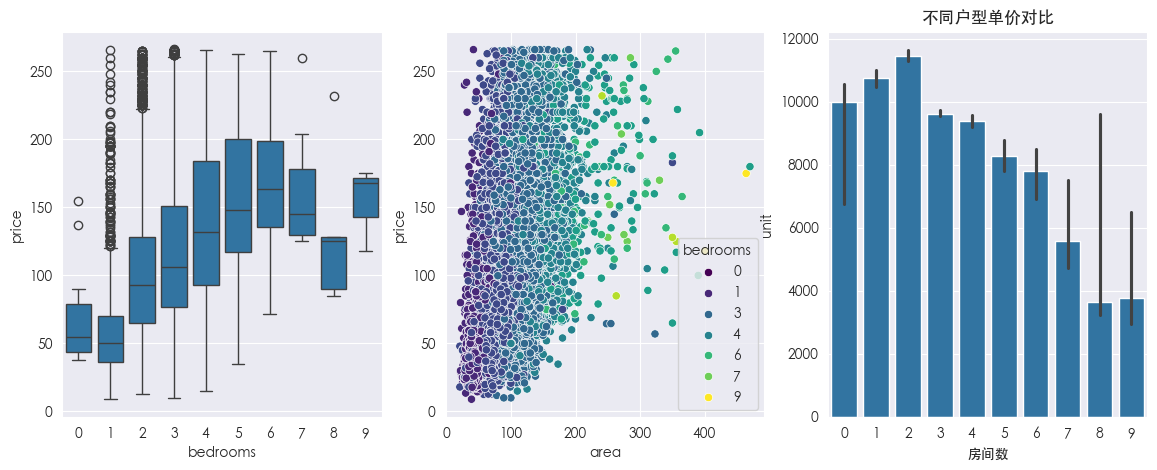

In [150]:
'''
问题编号: A5
问题: 哪种户型最受欢迎？三室比两室贵多少？
分析主题: 户型分析
分析目标: 分析不同户型的市场表现
分组字段: rooms
指标/方法: 占比/平均单价/溢价率
'''
rooms_sort = df['bedrooms'].value_counts().sort_values(ascending=False)
bedrooms_group = df.groupby('bedrooms').agg({
    'price':'mean',
    'unit':'mean'
}).sort_values('price')

plt.figure(figsize=(14,5))
plt.subplot(131)
sns.boxplot(data=df,x='bedrooms',y='price')

plt.subplot(132)
sns.scatterplot(data=df,x='area',y='price',hue='bedrooms',palette='viridis')

plt.subplot(133)`
sns.barplot(x='bedrooms', y='unit', data=df, estimator=np.median)
plt.title('不同户型单价对比')
plt.xlabel('房间数')

In [94]:
q'''
问题编号: A6
问题: 南北向是否真比单一朝向贵？贵多少？
分析主题: 朝向溢价
分析目标: 评估不同朝向的价格差异
分组字段: toward
指标/方法: 方差分析/多重比较
'''
df['toward'].value_counts()
df.groupby('toward').agg({
    'price':['mean','median'],
    'unit':'mean',
    'building_age':'mean'
})

price                 unit building_age
              mean median          mean         mean
toward                                              
东北向     111.439903  100.0  12231.398058    13.446602
东南向     111.175579  102.0  11529.487368    11.931579
东向      106.186439   90.0  11949.226829    13.682927
东西向      97.674667   82.0  10792.760000    16.533333
北向       89.504724   75.0  12226.586614    14.177165
南北向     114.196544  100.0  10840.926794    13.023847
南向      109.883707  100.0  11761.837772    12.541696
西北向     113.793101  105.0  12900.178295    14.410853
西南向     133.369959  130.0  14369.403292    14.526749
西向       96.946346   84.0  13288.230769    14.346154

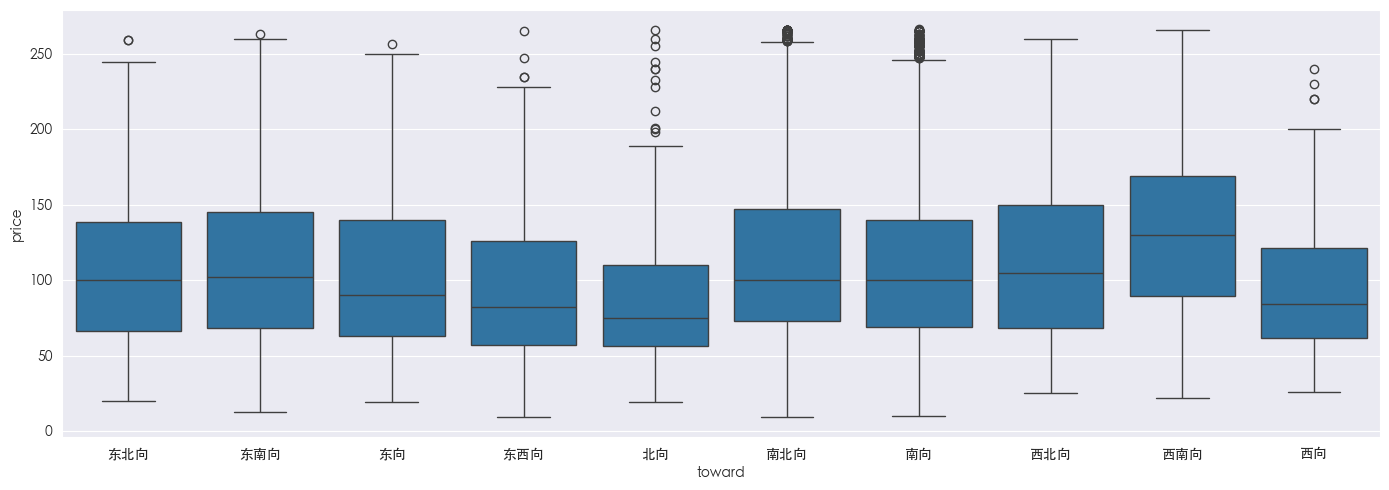

In [98]:
# 数据可视化
plt.figure(figsize=(14,5))
sns.boxplot(x='toward',y='price',data=df)
plt.tight_layout()